# Baseline Model — Admisiones de Posgrado

### By:
SCO

### Date:
2026-08-19

### Description:

Notebook del Issue #5. Evalúa dos baselines de regresión: Baseline 0,
`DummyRegressor(strategy="mean")` (referencia no informada), y Baseline 1, una
heurística simple basada en CGPA (referencia informada). Ambos flujos se evalúan con
el mismo split y Cross Validation; la heurística resultó ganadora y queda como
baseline principal. Las transformaciones y parámetros aprendidos permanecen dentro
de sus respectivos Pipelines para evitar data leakage y establecer una referencia
reproducible para modelos posteriores.

## Contexto, objetivo y alcance

El problema consiste en estimar `Chance of Admit`, un target de regresión almacenado
en escala **0–1**. El objetivo de este notebook no es encontrar el mejor modelo, sino
establecer dos referencias y comprobar si una regla muy simple, motivada por el EDA,
ofrece una referencia más exigente que predecir siempre la media. `Baseline 0` es
`DummyRegressor(strategy="mean")` (referencia no informada); `Baseline 1` es una
heurística de bandas de CGPA (referencia informada). La heurística resultó ganadora
de forma consistente en Cross Validation y se selecciona como baseline principal,
mientras el Dummy permanece como referencia no informada.

Se trabaja con el Parquet intermedio del proyecto. Los duplicados exactos se eliminan
antes del split, y el Test se reserva para la evaluación final posterior a la selección
por Cross Validation. No se crean las features hipotéticas identificadas en el EDA
(`CGPA + GRE`, `University Rating × Research` y `CGPA × Research`), porque pertenecen
a experimentos posteriores.

## 📚 Import libraries

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    KFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.utils.validation import check_is_fitted

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.13
pandas: 3.0.5
NumPy: 2.5.2
scikit-learn: 1.9.0


## 💾 Load data

In [2]:
def find_repo_root(start: Path) -> Path:
    """Locate the repository root by searching for pyproject.toml."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find the repository root.")


ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "data" / "02_intermediate" / "Admission_Predict.parquet"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

admission_df = pd.read_parquet(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Initial shape: {admission_df.shape}")
admission_df.head()

Dataset loaded from: /home/elkiruvi/Proyecto-Admisiones/data/02_intermediate/Admission_Predict.parquet
Initial shape: (623, 8)


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


### Schema and target validation

The expected dimensions below describe the current project dataset. They are
validated dynamically here, but they are not universal rules for future datasets.
The target remains in its original 0–1 scale and is not included in the predictors.

In [3]:
target = "Chance of Admit"
expected_columns = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
    target,
]

assert list(admission_df.columns) == expected_columns
assert target in admission_df.columns
assert admission_df[target].notna().all()
assert admission_df[target].between(0.0, 1.0).all()

print("Columns validated:", list(admission_df.columns))
print("Target:", target)
print("Target range: [" f"{admission_df[target].min():.2f}, " f"{admission_df[target].max():.2f}]")
print("Missing values by column:")
print(admission_df.isna().sum().to_string())

Columns validated: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']
Target: Chance of Admit
Target range: [0.34, 0.97]
Missing values by column:
GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0


## 👷 Data preparation or Feature Engineering

### Duplicates and Train/Test split

Exact duplicates are removed in memory before the split. This prevents identical
records from appearing in both Train and Test. The current dataset is expected to
contain 623 rows, 152 exact duplicates and 471 unique records.

In [4]:
initial_rows = len(admission_df)
n_duplicates = int(admission_df.duplicated().sum())
admission_unique_df = admission_df.drop_duplicates().reset_index(drop=True)
unique_rows = len(admission_unique_df)

current_snapshot = {
    "initial_rows": initial_rows,
    "exact_duplicates": n_duplicates,
    "unique_rows": unique_rows,
}
expected_current_snapshot = {"initial_rows": 623, "exact_duplicates": 152, "unique_rows": 471}

print("Current dataset snapshot:", current_snapshot)
print("Matches the current Issue #5 reference snapshot:", current_snapshot == expected_current_snapshot)
assert unique_rows == initial_rows - n_duplicates
assert not admission_unique_df.duplicated().any()

numeric_features = ["GRE Score", "TOEFL Score", "CGPA"]
ordinal_features = ["University Rating", "SOP", "LOR"]
binary_features = ["Research"]
feature_columns = numeric_features + ordinal_features + binary_features

X = admission_unique_df[feature_columns]
y = admission_unique_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

assert set(X_train.index).isdisjoint(set(X_test.index))
assert len(X_train) + len(X_test) == len(admission_unique_df)
assert (len(X_train), len(X_test)) == (376, 95)

print(f"Train shape: {X_train.shape}, target: {y_train.shape}")
print(f"Test shape: {X_test.shape}, target: {y_test.shape}")
print("Train and Test indices are disjoint: True")

Current dataset snapshot: {'initial_rows': 623, 'exact_duplicates': 152, 'unique_rows': 471}
Matches the current Issue #5 reference snapshot: True
Train shape: (376, 7), target: (376,)
Test shape: (95, 7), target: (95,)
Train and Test indices are disjoint: True


### Reconstruction of the Issue #4 preprocessing

The preprocessor is rebuilt as an unfitted object. It is not applied globally before
Cross Validation. Instead, it is placed inside the same Pipeline as the estimator,
so every fold learns its own imputation statistics, encoding and scaling parameters.
No additional features are created in this baseline.

In [5]:
ordinal_categories = [
    [1, 2, 3, 4, 5],
    [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
]


def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    ordinal_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(categories=ordinal_categories)),
            ("scaler", StandardScaler()),
        ]
    )

    binary_pipeline = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="most_frequent"))]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("ordinal", ordinal_pipeline, ordinal_features),
            ("binary", binary_pipeline, binary_features),
        ]
    )


preprocessor = build_preprocessor()
print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['GRE Score', 'TOEFL Score', 'CGPA']),
                                ('ordinal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[[1,
                                                                              2,
                                                                              3,
                                                                              4,
                                                                           

## Baseline models

Baseline 0 is `DummyRegressor(strategy="mean")`: it ignores every predictor and
predicts the mean target observed during `fit`. It is the non-informed reference.
Baseline 1 is a CGPA band heuristic: the CGPA scale is divided into three fixed,
interpretable intervals (`<8.5`, `8.5–<9.0` and `>=9.0`) and each interval predicts
its training target mean. It is the informed reference and, as shown by the CV
results below, the selected primary baseline.

### Origin of the band boundaries

The cut points 8.5 and 9.0 are predefined, round values on the CGPA scale chosen to
produce a deliberately coarse and interpretable rule motivated by the EDA association
between CGPA and the target. They were not selected by optimizing against Test, and
no multiple combinations of cut points were tried to pick the best one. This notebook
does not document an optimization history for the cuts, so the boundaries must be
understood as fixed predefined bands for a simple heuristic, not as tuned
hyper-parameters.

The imputation and the per-band target means are learned inside the Pipeline in every
CV fold and again using all Train data before the final Test evaluation. This is a
deliberately small supervised lookup heuristic, not a replacement for the models in
later Issues.

In [6]:
class CGPABinnedMeanRegressor(BaseEstimator, RegressorMixin):
    """Predict the training target mean for fixed CGPA bands."""

    def __init__(self, bin_edges=(0.0, 8.5, 9.0, np.inf)):
        self.bin_edges = bin_edges

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        if X.ndim != 2 or X.shape[1] != 1:
            raise ValueError("CGPA heuristic expects exactly one feature.")
        if len(self.bin_edges) < 2 or not np.all(np.diff(self.bin_edges) > 0):
            raise ValueError("bin_edges must be strictly increasing.")

        self.global_mean_ = float(np.mean(y))
        bin_ids = np.digitize(X[:, 0], self.bin_edges[1:-1], right=False)
        self.bin_means_ = np.array([
            float(np.mean(y[bin_ids == bin_id]))
            if np.any(bin_ids == bin_id)
            else self.global_mean_
            for bin_id in range(len(self.bin_edges) - 1)
        ])
        return self

    def predict(self, X):
        check_is_fitted(self, ["global_mean_", "bin_means_"])
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != 1:
            raise ValueError("CGPA heuristic expects exactly one feature.")
        bin_ids = np.digitize(X[:, 0], self.bin_edges[1:-1], right=False)
        return self.bin_means_[bin_ids]


baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean")),
    ]
)

print(baseline_pipeline)
print("Preprocessor fitted before Cross Validation:", hasattr(preprocessor, "transformers_"))
assert not hasattr(preprocessor, "transformers_")
heuristic_preprocessor = ColumnTransformer(
    transformers=[("cgpa", SimpleImputer(strategy="median"), ["CGPA"])],
    remainder="drop",
)
heuristic_pipeline = Pipeline(
    steps=[
        ("cgpa_preprocessor", heuristic_preprocessor),
        ("model", CGPABinnedMeanRegressor()),
    ]
)

baseline_models = {
    "DummyRegressor": baseline_pipeline,
    "CGPA band heuristic": heuristic_pipeline,
}

print("Baselines prepared:", list(baseline_models))
assert not hasattr(heuristic_preprocessor, "transformers_")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['GRE Score', 'TOEFL Score',
                                                   'CGPA']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[[

## Evaluation metrics and Cross Validation

RMSE is the primary metric because it penalizes large errors while preserving the
target units. MAE reports the average absolute error in the same 0–1 scale. R² is
complementary and indicates whether a model improves over the mean reference; it may
be negative when predictions are worse than that reference.

The validation process uses only Train. Both baselines use exactly the same
`KFold(n_splits=5, shuffle=True, random_state=42)`. The negative error scorers
returned by scikit-learn are converted to positive MAE and RMSE values for
presentation. The comparison and the primary-baseline decision use CV first; Test
is not consulted until after that decision.

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_results_by_model = {}
cv_fold_results_by_model = {}
cv_summary_rows = []

for model_name, model in baseline_models.items():
    results = cross_validate(
        model,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        return_train_score=True,
        return_estimator=False,
        n_jobs=1,
        error_score="raise",
    )
    cv_results_by_model[model_name] = results
    cv_fold_results_by_model[model_name] = pd.DataFrame(
        {
            "Model": model_name,
            "Fold": np.arange(1, cv.get_n_splits() + 1),
            "Train MAE": -results["train_mae"],
            "Validation MAE": -results["test_mae"],
            "Train RMSE": -results["train_rmse"],
            "Validation RMSE": -results["test_rmse"],
            "Train R2": results["train_r2"],
            "Validation R2": results["test_r2"],
        }
    )
    cv_summary_rows.append(
        {
            "Model": model_name,
            "CV MAE mean": -results["test_mae"].mean(),
            "CV MAE std": results["test_mae"].std(),
            "CV RMSE mean": -results["test_rmse"].mean(),
            "CV RMSE std": results["test_rmse"].std(),
            "CV R2 mean": results["test_r2"].mean(),
            "CV R2 std": results["test_r2"].std(),
        }
    )

# cross_validate clones every estimator, so the original pipelines remain unfitted.
assert not hasattr(baseline_pipeline.named_steps["preprocessor"], "transformers_")
assert not hasattr(heuristic_preprocessor, "transformers_")

cv_fold_results = pd.concat(cv_fold_results_by_model.values(), ignore_index=True)
print("Fold-level validation results for both baselines:")
cv_fold_results.round(4)

Fold-level validation results for both baselines:


,Model,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,DummyRegressor,1,0.1164,0.1048,0.1462,0.1261,0.0000,-0.0262
1,DummyRegressor,2,0.1116,0.1237,0.1398,0.1520,0.0000,-0.0143
2,DummyRegressor,3,0.1118,0.1228,0.1382,0.1578,0.0000,-0.0107
3,DummyRegressor,4,0.1137,0.1153,0.1418,0.1449,0.0000,-0.0375
4,DummyRegressor,5,0.1164,0.1045,0.1451,0.1305,0.0000,-0.0017
5,CGPA band heuristic,1,0.0719,0.0623,0.0922,0.0774,0.6022,0.6132
6,CGPA band heuristic,2,0.0697,0.0720,0.0897,0.0883,0.5889,0.6578
7,CGPA band heuristic,3,0.0683,0.0729,0.0871,0.0986,0.6024,0.6053
8,CGPA band heuristic,4,0.0692,0.0707,0.0877,0.0960,0.6170,0.5449
9,CGPA band heuristic,5,0.0695,0.0747,0.0892,0.0909,0.6224,0.5137


In [8]:
cv_summary_comparison = pd.DataFrame(cv_summary_rows)

print("Cross Validation summary (validation folds only):")
cv_summary_comparison.round(4)

Cross Validation summary (validation folds only):


,Model,CV MAE mean,CV MAE std,CV RMSE mean,CV RMSE std,CV R2 mean,CV R2 std
0,DummyRegressor,0.1142,0.0083,0.1423,0.0122,-0.0181,0.0125
1,CGPA band heuristic,0.0705,0.0043,0.0902,0.0074,0.5870,0.0513


## Final evaluation on Test

The primary baseline is selected using only the Cross Validation summary, prioritizing
lower RMSE and then lower MAE. Only after that decision are both complete Pipelines
fitted on all Train data and evaluated once on Test. The Test values are reported for
objective confirmation, not used to choose the winner. The transformed data is
inspected after fitting to validate the expected features and absence of NaN.

In [9]:
selection_order = cv_summary_comparison.sort_values(
    by=["CV RMSE mean", "CV MAE mean"],
    ascending=[True, True],
).reset_index(drop=True)
selected_baseline_name = selection_order.loc[0, "Model"]
selected_baseline = baseline_models[selected_baseline_name]

print("Baseline selected using CV only:", selected_baseline_name)
print("Selection priority: lower CV RMSE, then lower CV MAE.")

fitted_baselines = {}
test_rows = []
train_metrics_by_model = {}
predictions_by_model = {}

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    fitted_baselines[model_name] = model
    predictions_by_model[model_name] = test_predictions
    train_metrics_by_model[model_name] = {
        "Train MAE": mean_absolute_error(y_train, train_predictions),
        "Train RMSE": root_mean_squared_error(y_train, train_predictions),
        "Train R2": r2_score(y_train, train_predictions),
    }
    test_rows.append(
        {
            "Model": model_name,
            "Test MAE": mean_absolute_error(y_test, test_predictions),
            "Test RMSE": root_mean_squared_error(y_test, test_predictions),
            "Test R2": r2_score(y_test, test_predictions),
        }
    )

test_comparison = pd.DataFrame(test_rows)
comparison_table = cv_summary_comparison.merge(test_comparison, on="Model")

dummy_constant = float(
    np.asarray(fitted_baselines["DummyRegressor"].named_steps["model"].constant_)
.ravel()[0]
)
assert np.isclose(dummy_constant, y_train.mean())
assert np.allclose(predictions_by_model["DummyRegressor"], dummy_constant)
assert selected_baseline_name in baseline_models

print("Final comparison: CV first, Test reported afterward")
comparison_table.round(4)

Baseline selected using CV only: CGPA band heuristic
Selection priority: lower CV RMSE, then lower CV MAE.
Final comparison: CV first, Test reported afterward


,Model,CV MAE mean,CV MAE std,CV RMSE mean,CV RMSE std,CV R2 mean,CV R2 std,Test MAE,Test RMSE,Test R2
0,DummyRegressor,0.1142,0.0083,0.1423,0.0122,-0.0181,0.0125,0.1210,0.1485,-0.0000
1,CGPA band heuristic,0.0705,0.0043,0.0902,0.0074,0.5870,0.0513,0.0724,0.0919,0.6168


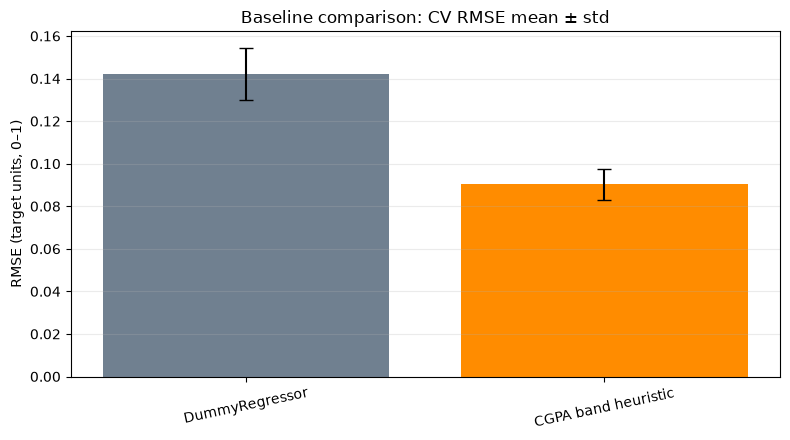

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(
    comparison_table["Model"],
    comparison_table["CV RMSE mean"],
    yerr=comparison_table["CV RMSE std"],
    capsize=5,
    color=["slategray", "darkorange"],
)
ax.set_title("Baseline comparison: CV RMSE mean ± std")
ax.set_ylabel("RMSE (target units, 0–1)")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=12)
fig.tight_layout()
plt.show()

In [11]:
fitted_preprocessor = baseline_pipeline.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

assert len(feature_names) == 7
assert X_train_processed.shape == (len(X_train), 7)
assert X_test_processed.shape == (len(X_test), 7)
assert not np.isnan(X_train_processed).any()
assert not np.isnan(X_test_processed).any()

print("Processed feature names:")
for name in feature_names:
    print(" -", name)
print(f"Processed Train shape: {X_train_processed.shape}")
print(f"Processed Test shape: {X_test_processed.shape}")
print("NaN after preprocessing: 0")

fitted_heuristic_preprocessor = fitted_baselines["CGPA band heuristic"].named_steps["cgpa_preprocessor"]
heuristic_feature_names = fitted_heuristic_preprocessor.get_feature_names_out()
X_train_cgpa = fitted_heuristic_preprocessor.transform(X_train)
X_test_cgpa = fitted_heuristic_preprocessor.transform(X_test)
assert list(heuristic_feature_names) == ["cgpa__CGPA"]
assert X_train_cgpa.shape == (len(X_train), 1)
assert X_test_cgpa.shape == (len(X_test), 1)
assert not np.isnan(X_train_cgpa).any()
assert not np.isnan(X_test_cgpa).any()
print("Heuristic processed feature: CGPA only; NaN after imputation: 0")

Processed feature names:
 - numeric__GRE Score
 - numeric__TOEFL Score
 - numeric__CGPA
 - ordinal__University Rating
 - ordinal__SOP
 - ordinal__LOR
 - binary__Research
Processed Train shape: (376, 7)
Processed Test shape: (95, 7)
NaN after preprocessing: 0
Heuristic processed feature: CGPA only; NaN after imputation: 0


## Target distribution

The histogram shows the target distribution on Train. The dashed vertical line is the
Train mean used by `DummyRegressor`, which remains the non-informed reference. The
CGPA band heuristic cannot be represented by a single horizontal line: it uses CGPA
to produce differentiated predictions per band.

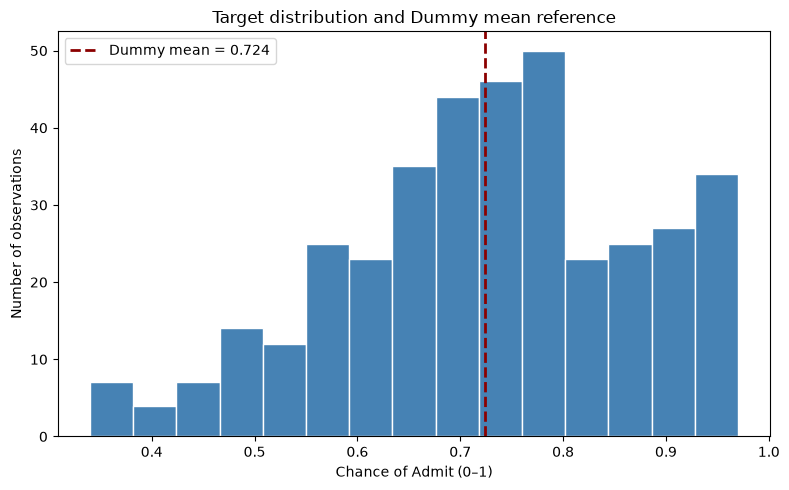

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_train, bins=15, color="steelblue", edgecolor="white")
ax.axvline(
    y_train.mean(),
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Dummy mean = {y_train.mean():.3f}",
)
ax.set_title("Target distribution and Dummy mean reference")
ax.set_xlabel("Chance of Admit (0–1)")
ax.set_ylabel("Number of observations")
ax.legend()
fig.tight_layout()
plt.show()

## Variable más importante: evidencia del EDA

`DummyRegressor` no aprende relaciones entre X e y, por lo que no posee
`feature_importances_` ni coeficientes interpretables. No se inventa una importancia
para este modelo.

1. **Asociación bivariada:** `CGPA` presentó la mayor asociación observada en el EDA
(Pearson ≈ 0.883; Spearman ≈ 0.890), con relación positiva y aproximadamente lineal.
2. **Feature importance:** ninguno de los dos baselines entrega importancia de
features formal; el Dummy ignora X y la heurística solo usa CGPA por construcción.
3. **Heurística:** sus bandas son una regla basada en evidencia exploratoria. Su
mejora respecto al Dummy demuestra que una regla gruesa basada únicamente en CGPA
tiene señal predictiva en este dataset, pero NO demuestra causalidad ni importancia
independiente de CGPA.
4. **Modelos posteriores:** GRE, TOEFL y CGPA también están fuertemente correlacionados
y pueden aportar información redundante; su importancia conjunta debe evaluarse con
modelos que aprendan relaciones multivariables. Correlación no implica causalidad.

In [13]:
eda_evidence = pd.DataFrame(
    {
        "Concept": ["Selected variable", "Pearson association", "Spearman association", "Model importance", "Heuristic rule"],
        "Value": ["CGPA", 0.883, 0.890, "Not available for either baseline", "Three fixed CGPA bands"],
        "Interpretation": [
            "Highest bivariate association reported in Issue #3 EDA",
            "Strong positive exploratory association",
            "Strong positive monotonic exploratory association",
            "Neither baseline learns general feature importance",
            "Training target mean per fixed band; no Test-derived rule",
        ],
    }
)
eda_evidence

,Concept,Value,Interpretation
0,Selected variable,CGPA,Highest bivariate association reported in Issu...
1,Pearson association,0.883,Strong positive exploratory association
2,Spearman association,0.89,Strong positive monotonic exploratory association
3,Model importance,Not available for either baseline,Neither baseline learns general feature import...
4,Heuristic rule,Three fixed CGPA bands,Training target mean per fixed band; no Test-d...


## Learning Curve

The Learning Curve uses RMSE as the primary metric and only the Train partition. It is
computed on the selected primary baseline, the CGPA band heuristic, so the curve now
represents the reference that future models must beat. Shaded regions represent one
standard deviation across the validation folds. The following cell reports the observed
ranges and the largest train-validation gap. Although the heuristic uses CGPA, it is
still a simple rule; the curve must not be read as evidence that a definitive ML model
has been built.

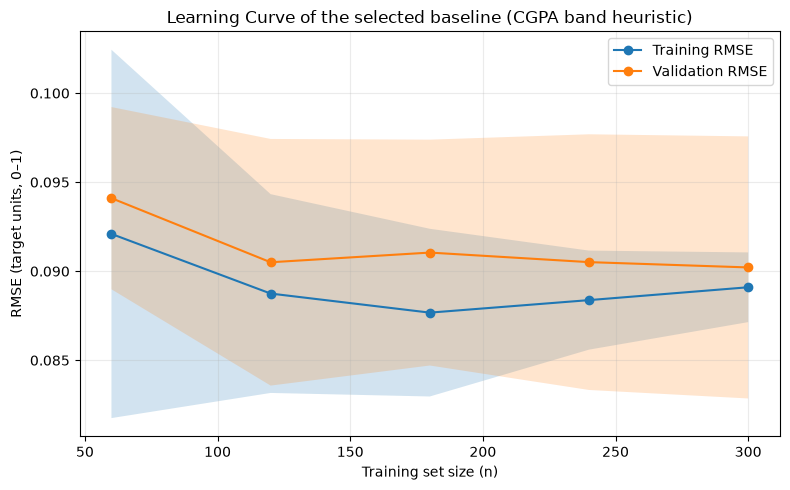

In [14]:
train_sizes, train_scores, validation_scores, fit_times, score_times = learning_curve(
    selected_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    shuffle=True,
    random_state=42,
    return_times=True,
    n_jobs=1,
    error_score="raise",
)

train_rmse = -train_scores
validation_rmse = -validation_scores

fig, ax = plt.subplots(figsize=(8, 5))
train_mean = train_rmse.mean(axis=1)
train_std = train_rmse.std(axis=1)
validation_mean = validation_rmse.mean(axis=1)
validation_std = validation_rmse.std(axis=1)

ax.plot(train_sizes, train_mean, marker="o", label="Training RMSE")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
ax.plot(train_sizes, validation_mean, marker="o", label="Validation RMSE")
ax.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.2,
)
ax.set_title("Learning Curve of the selected baseline (CGPA band heuristic)")
ax.set_xlabel("Training set size (n)")
ax.set_ylabel("RMSE (target units, 0–1)")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [15]:
learning_curve_summary = pd.DataFrame(
    {
        "Training size": train_sizes,
        "Training RMSE mean": train_mean,
        "Validation RMSE mean": validation_mean,
        "Validation RMSE std": validation_std,
    }
)
learning_curve_summary.round(4)
print(
    f"Learning Curve observation: training RMSE ranges from {train_mean.min():.4f} "
    f"to {train_mean.max():.4f}; validation RMSE ranges from "
    f"{validation_mean.min():.4f} to {validation_mean.max():.4f}."
)
print(
    f"The largest mean train-validation gap is {np.max(validation_mean - train_mean):.4f}; "
    f"validation standard deviation ranges from {validation_std.min():.4f} to {validation_std.max():.4f}."
)
print("Interpretation: this curve measures the stability and sample-size sensitivity of the CGPA heuristic rule, not evidence that a definitive ML model has been built.")

Learning Curve observation: training RMSE ranges from 0.0877 to 0.0921; validation RMSE ranges from 0.0902 to 0.0941.
The largest mean train-validation gap is 0.0034; validation standard deviation ranges from 0.0051 to 0.0074.
Interpretation: this curve measures the stability and sample-size sensitivity of the CGPA heuristic rule, not evidence that a definitive ML model has been built.


## Training and scoring scalability

`learning_curve(..., return_times=True)` returns the time required to fit and score
each fold for each training size, now measured on the selected primary baseline (the
CGPA band heuristic), including its median imputation of CGPA and the per-band target
means. The following visualization reports the mean and standard deviation in seconds.
These values describe this small heuristic pipeline on a dataset with only 471 unique
observations; they must not be generalized to production scalability.

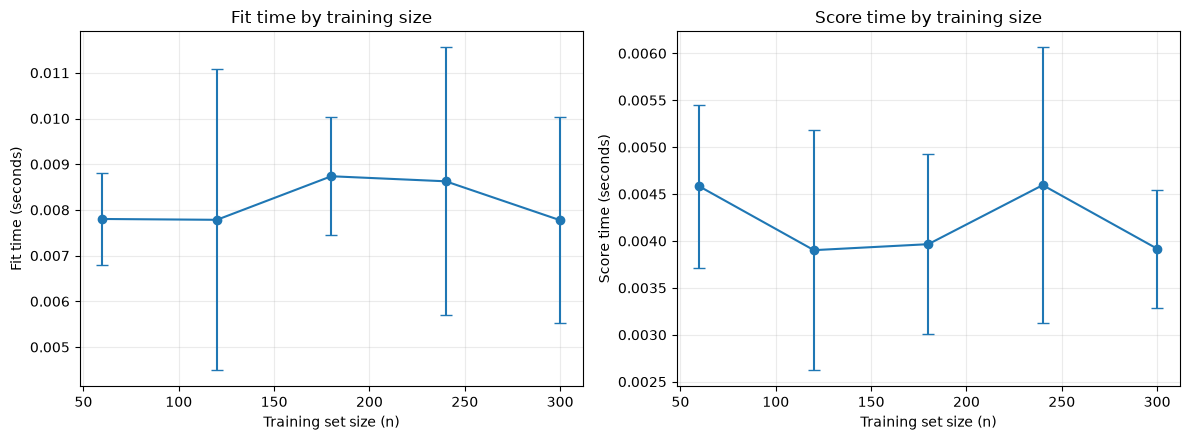

Scalability observation: fit and score times are very small and vary little across the five sizes.
Limitation: 471 unique observations are insufficient to extrapolate general production scalability.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].errorbar(
    train_sizes,
    fit_times.mean(axis=1),
    yerr=fit_times.std(axis=1),
    marker="o",
    capsize=4,
)
axes[0].set_title("Fit time by training size")
axes[0].set_xlabel("Training set size (n)")
axes[0].set_ylabel("Fit time (seconds)")
axes[0].grid(alpha=0.25)

axes[1].errorbar(
    train_sizes,
    score_times.mean(axis=1),
    yerr=score_times.std(axis=1),
    marker="o",
    capsize=4,
)
axes[1].set_title("Score time by training size")
axes[1].set_xlabel("Training set size (n)")
axes[1].set_ylabel("Score time (seconds)")
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

timing_summary = pd.DataFrame(
    {
        "Training size": train_sizes,
        "Fit time mean (s)": fit_times.mean(axis=1),
        "Fit time std (s)": fit_times.std(axis=1),
        "Score time mean (s)": score_times.mean(axis=1),
        "Score time std (s)": score_times.std(axis=1),
    }
)
timing_summary.round(6)
print("Scalability observation: fit and score times are very small and vary little across the five sizes.")
print("Limitation: 471 unique observations are insufficient to extrapolate general production scalability.")

## 📊 Analysis of Results and Conclusions

The table must be read in two stages. First, CV estimates how consistently each
baseline performs across the five Train folds. Second, the independent Test result
confirms the selected reference once, without becoming another tuning fold.

For the Dummy, CV MAE ≈ 0.1142 ± 0.0083 and CV RMSE ≈ 0.1423 ± 0.0122, while Test
MAE ≈ 0.1210 and Test RMSE ≈ 0.1485. The small increase in Test RMSE is compatible
with ordinary sample variation between folds and the held-out split. Its CV R²
≈ -0.0181 ± 0.0125 is slightly negative because each fold uses a training mean that
can differ from that fold's validation mean. Test R² ≈ 0 is expected: predicting the
Train mean is conceptually the mean-reference benchmark, although the Test mean can
differ slightly. R² is not a percentage of accuracy.

The Dummy ignores all seven features. Therefore this result is a non-informed
reference, not evidence that the dataset has no predictive signal. The CGPA heuristic
tests whether the strongest EDA association is already useful in a deliberately
coarse rule. The fold-level results and the following cell determine whether that
improvement is consistent rather than relying on a single Test value.

In [17]:
dummy = comparison_table.loc[comparison_table["Model"] == "DummyRegressor"].iloc[0]
selected = comparison_table.loc[comparison_table["Model"] == selected_baseline_name].iloc[0]
rmse_gain_cv = dummy["CV RMSE mean"] - selected["CV RMSE mean"]
rmse_gain_test = dummy["Test RMSE"] - selected["Test RMSE"]
rmse_gain_cv_rel = rmse_gain_cv / dummy["CV RMSE mean"] * 100
rmse_gain_test_rel = rmse_gain_test / dummy["Test RMSE"] * 100
heuristic_fold_rmse = cv_fold_results_by_model["CGPA band heuristic"]["Validation RMSE"]
dummy_fold_rmse = cv_fold_results_by_model["DummyRegressor"]["Validation RMSE"]

print(f"Selected baseline: {selected_baseline_name}")
print(f"CV RMSE: Dummy = {dummy['CV RMSE mean']:.4f} ± {dummy['CV RMSE std']:.4f}; "
      f"selected = {selected['CV RMSE mean']:.4f} ± {selected['CV RMSE std']:.4f}")
print(f"Test RMSE: Dummy = {dummy['Test RMSE']:.4f}; selected = {selected['Test RMSE']:.4f}")
print(f"RMSE reduction: {rmse_gain_cv:.4f} in CV ({rmse_gain_cv_rel:.1f}%) and "
      f"{rmse_gain_test:.4f} on Test ({rmse_gain_test_rel:.1f}%).")
print(f"CV MAE: Dummy = {dummy['CV MAE mean']:.4f}; selected = {selected['CV MAE mean']:.4f}.")
print(f"CV R2: Dummy = {dummy['CV R2 mean']:.4f}; selected = {selected['CV R2 mean']:.4f}.")
print("The CGPA heuristic has lower RMSE in every validation fold:", bool(np.all(heuristic_fold_rmse < dummy_fold_rmse)))
print("The five-fold consistency is evidence of a stable improvement, but it is not a formal statistical test.")
print(f"Dummy CV/Test RMSE difference: {dummy['Test RMSE'] - dummy['CV RMSE mean']:.4f}.")
print("R2 interpretation: R2 = 0 is the mean-reference concept; a negative value is possible when the fitted Train mean is worse than the evaluated-split mean.")
print("R2 is not accuracy and not causality. The heuristic's positive R2 reflects CGPA-based differentiated predictions.")
print("The selected baseline is a coarse CGPA reference, not a causal explanation or a final predictive model.")
print("Future models must improve this reference using the same split, CV protocol and leakage-safe pipelines.")

Selected baseline: CGPA band heuristic
CV RMSE: Dummy = 0.1423 ± 0.0122; selected = 0.0902 ± 0.0074
Test RMSE: Dummy = 0.1485; selected = 0.0919
RMSE reduction: 0.0520 in CV (36.6%) and 0.0566 on Test (38.1%).
CV MAE: Dummy = 0.1142; selected = 0.0705.
CV R2: Dummy = -0.0181; selected = 0.5870.
The CGPA heuristic has lower RMSE in every validation fold: True
The five-fold consistency is evidence of a stable improvement, but it is not a formal statistical test.
Dummy CV/Test RMSE difference: 0.0062.
R2 interpretation: R2 = 0 is the mean-reference concept; a negative value is possible when the fitted Train mean is worse than the evaluated-split mean.
R2 is not accuracy and not causality. The heuristic's positive R2 reflects CGPA-based differentiated predictions.
The selected baseline is a coarse CGPA reference, not a causal explanation or a final predictive model.
Future models must improve this reference using the same split, CV protocol and leakage-safe pipelines.


### Conclusions

La heurística `CGPA band heuristic` fue seleccionada como baseline principal porque
mejoró al Dummy en RMSE y MAE en los cinco folds de CV y mantuvo la mejora en Test
(RMSE aproximado: 0.0902 en CV y 0.0919 en Test, frente a 0.1423 y 0.1485 del
Dummy). La reducción de error es consistente, por lo que la regla ofrece una
referencia más exigente para los modelos siguientes.

El baseline elegido representa una asociación predictiva univariada y gruesa entre
CGPA y el target: no representa causalidad, importancia multivariable ni el mejor
modelo posible. El Dummy se conserva como referencia no informada y su R² cercano a
cero sigue siendo el comportamiento esperado de una predicción constante.

La heurística también tiene limitaciones: descarta GRE, TOEFL y las demás variables,
impone bandas fijas y resume cada banda con una media. Su mejora no autoriza a
generalizar fuera de este dataset; los modelos posteriores deben evaluarla contra el
mismo protocolo y comprobar si la señal permanece al considerar correlación y efectos
multivariables.

## 💡 Proposals and Ideas

The next modeling stage should compare the selected CGPA heuristic against an
interpretable `LinearRegression` and regularized alternatives such as `Ridge`, `Lasso`
or `ElasticNet`. `Ridge` is especially relevant because GRE, TOEFL and CGPA are
strongly correlated. Future experiments may evaluate `CGPA + GRE`,
`University Rating × Research`, `CGPA × Research` or a score composite, but they must
be added inside reproducible pipelines and compared against both baselines without
reusing Test for tuning.

Feature importance should be evaluated only with models that learn relationships, using
appropriate coefficients or model-agnostic methods in a later Issue.

## 📖 References

- `data/02_intermediate/Admission_Predict.parquet`.
- `notebooks/4-feat_eng/04.1-SCO_feature_engineering-2026_08_19.ipynb`.
- `notebooks/3-analysis/03.2-SCO_bivariate_analysis-2026_08_19.ipynb`.
- `notebooks/3-analysis/03.3-SCO_multivariate_analysis-2026_08_19.ipynb`.
- scikit-learn documentation: `Pipeline`, `ColumnTransformer`, `DummyRegressor`,
  `BaseEstimator`, `RegressorMixin`, `cross_validate` and `learning_curve`.
- `notebooks/README.md` — notebook naming convention.
- `AGENTS.md` — project rules for data leakage, reproducibility and validation.